# I'm having a look at the weight matricies of Roberta and exploring SVD to inform my application of Lora to roberta

In [ ]:
from transformers import AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt


# How to Select 'r'

I selected W^o at multiple layers in the RoBERTa model, and plotted the SVD, 
Sigma (diagonal matrix). I saw there was a clear signal that showed the downward 
trend of σ with respect to d_model. There was a familiar shape I've seen before 
in a scree plot. At the elbow was a noticeable change in the rate σ to d_model. 
My intuition was to use this r value. But I needed more grounded confirmation 
before moving forward. So I used the paper's approach of using 'Subspace 
Similarity' (SSS).

Formally:

$$\phi(A_{r=8}, A_{r=64}, i, j) = \frac{||U^i_{A_{r=8}} U^j_{A_{r=64}}||^2_F}{min(i,j)} \in [0,1]$$

In this case we lock j to some ridiculous number >> i. Then we choose some number 
for i << j. We run the formula for SSS. A similarity of 1 means i=8 has complete 
overlap with j=64. Here is the rank decomposition working for us. The lower rank 
of 8 covers as much information as 64. Also 8 covers more of the amplification 
factor than the larger 64.

## Benefit:
- No meaningful information lost
- Far less trainable params
- Stronger amplification for specific tasks
- Full overlap with the larger space

In [2]:
# Load completely fresh pretrained model
model = AutoModel.from_pretrained("roberta-base")
model.config

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.2.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

# Looking for WO,Wk,Wq,Wv then plotting svd of some layers to understand the decomposition of those matricies

In [31]:
#First layer attention and combonation of self attention
wq = model.encoder.layer[0].attention.self.query.weight.detach().numpy()
wk = model.encoder.layer[0].attention.self.key.weight.detach().numpy()
wv = wk = model.encoder.layer[0].attention.self.value.weight.detach().numpy()
wo = model.encoder.layer[0].attention.output.dense.weight.detach().numpy()

In [47]:
#peeking at last combined self attention layer
wo11 = model.encoder.layer[11].attention.output.dense.weight.detach().numpy()
wo11


array([[ 0.00104904,  0.00173187, -0.02651978, ..., -0.06561279,
         0.00628662, -0.04626465],
       [ 0.02748108,  0.01305389, -0.04656982, ..., -0.00585938,
         0.01268005,  0.01185608],
       [ 0.02423096, -0.01128387,  0.02203369, ...,  0.01151276,
        -0.01109314, -0.00456619],
       ...,
       [ 0.05871582,  0.0045433 ,  0.02153015, ...,  0.0002625 ,
         0.00356674, -0.0602417 ],
       [-0.07012939,  0.04888916, -0.01335907, ..., -0.05072021,
         0.05471802,  0.03833008],
       [-0.00616074,  0.00253105, -0.01187134, ..., -0.0076828 ,
        -0.01144409,  0.02961731]], shape=(768, 768), dtype=float32)

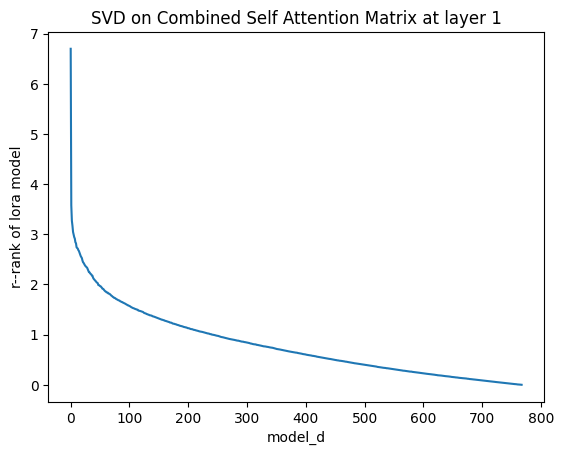

In [42]:
# Grab a weight matrix before any fine tuning
wq = model.encoder.layer[0].attention.self.query.weight.detach().numpy()

# Run SVD on any matrix
def run_svd(matrix):
    U, simga, VT = np.linalg.svd(matrix, full_matrices=False)
    return U,simga,VT
    

# Plot to see where values drop off

plt.plot(run_svd(wo)[1])
plt.xlabel('model_d')
plt.ylabel('r--rank of lora model')
plt.title("SVD on Combined Self Attention Matrix at layer 1")
plt.show()

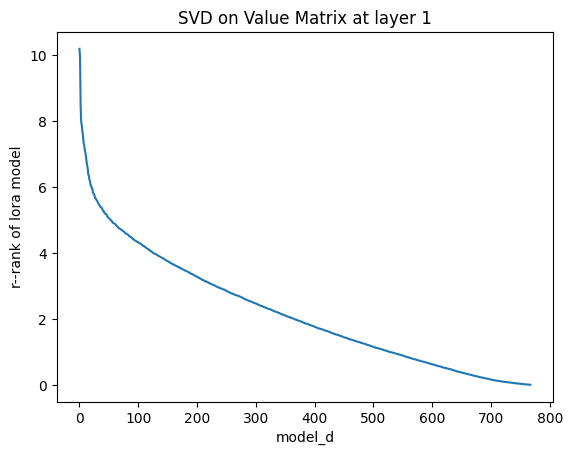

In [43]:
wv = model.encoder.layer[0].attention.self.key.weight.detach().numpy()
plt.plot(run_svd(wq)[1])
plt.xlabel('model_d')
plt.ylabel('r--rank of lora model')
plt.title("SVD on Value Matrix at layer 1")
plt.show()

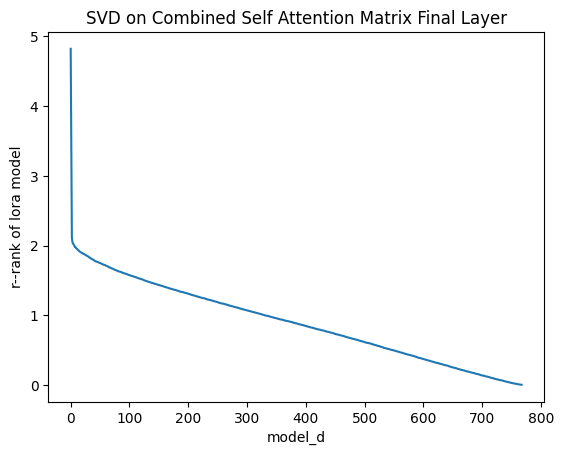

In [48]:
plt.plot(run_svd(wo11)[1])
plt.xlabel('model_d')
plt.ylabel('r--rank of lora model')
plt.title("SVD on Combined Self Attention Matrix Final Layer")
plt.show()

# This is directly from the Lora paper: https://arxiv.org/pdf/2106.09685

In [45]:
def subspace_similarity(A, B, i, j):
    # Get right singular vectors
    _, _, Ua = np.linalg.svd(A, full_matrices=False)
    _, _, Ub = np.linalg.svd(B, full_matrices=False)
    
    # Take top i and j singular vectors
    Ua_i = Ua[:i].T  # d x i
    Ub_j = Ub[:j].T  # d x j
    
    # Compute normalized subspace similarity
    phi = np.linalg.norm(Ua_i.T @ Ub_j, 'fro')**2 / min(i, j)
    return phi

In [49]:
# Compare a small r against a large reference r
wo__11r4 = wo11.copy()
wo__11r64 = wo11.copy()

# If phi is high between r=4 and r=64
# it means r=2 captures the same subspace as r=64
# meaning r=2 is sufficient
phi = subspace_similarity(wo__11r4, wo__11r64, i=2, j=64)
print(f"Subspace similarity: {phi}")
# Close to 1.0 = small r is sufficient
# Close to 0.0 = need larger r

Subspace similarity: 0.9999998211860657


# Using the final layer of the self attention matrix, applying SVD and computing the subspace similarity as discussed in the Lora study, we can observe the rank reduction from some large number of j to some reduced rank of i is sufficient to capture almost all of the information or our origiinal W^o matrix. 